# PLEM - Community Engagement
 This notebook will demonstrate the community engagement in Pittsburgh neighborhoods for a PLEM score.

In [3]:
import pandas as pd

In [4]:
attendance = pd.read_csv("daily-community-center.csv")
attendance

,_id,date,center_name,attendance_count
0,48956821,2025-11-08,Ormsby Community Center,1
1,48956822,2025-11-08,Paulson Community Center,3
2,48956823,2025-11-08,Phillips Community Center,1
3,48956824,2025-11-08,Warrington Community Center,12
4,48956825,2025-11-08,Magee Community Center,6
...,...,...,...,...
32243,48989064,2011-03-08,West Penn Community Center,3
32244,48989065,2011-03-08,Magee Community Center,32
32245,48989066,2011-03-07,Warrington Community Center,1
32246,48989067,2011-03-07,West Penn Community Center,2


# Finding annual attendance

In [14]:
attendance["date"] = pd.to_datetime(attendance["date"])
attendance["year"] = attendance["date"].dt.year
annual_attendance = attendance.groupby(["center_name", "year"])["attendance_count"].sum().reset_index()
annual_attendance

,center_name,year,attendance_count
0,Ammon Community Center,2011,11848
1,Ammon Community Center,2012,13683
2,Ammon Community Center,2013,10298
3,Ammon Community Center,2014,10950
4,Ammon Community Center,2015,23355
...,...,...,...
173,West Penn Community Center,2025,17068
174,West Penn Fields,2014,127
175,West Penn Pool,2011,35
176,West Penn Pool,2013,2


# Annual Attendance of past 5 years

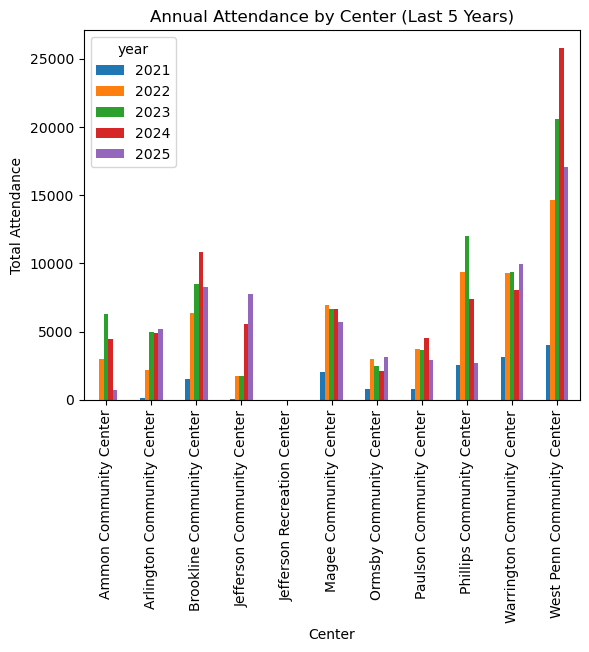

In [7]:
import matplotlib.pyplot as plt
latest_year = annual_attendance["year"].max()
last_5_years = annual_attendance[annual_attendance["year"] >= latest_year - 4]
attendance_pivot = last_5_years.pivot(
    index="center_name",
    columns="year",
    values="attendance_count"
)
attendance_pivot.plot(kind="bar")
plt.xlabel("Center")
plt.ylabel("Total Attendance")
plt.title("Annual Attendance by Center (Last 5 Years)")
plt.show()

# Year over year growth of each center

In [32]:
attendance_pivot = annual_attendance.pivot(
    index="center_name",
    columns="year",
    values="attendance_count"
)

yoy_growth = attendance_pivot.pct_change(axis=1, fill_method=None) * 100
yoy_growth = yoy_growth.round(2)
print(yoy_growth)

year                         2011    2012    2013     2014    2015   2016  \
center_name                                                                 
Ammon Community Center        NaN   15.49  -24.74     6.33  113.29   6.56   
Ammon Park                    NaN     NaN     NaN      NaN     NaN    NaN   
Ammon Pool                    NaN  -97.65     NaN      NaN     NaN    NaN   
Arlington Community Center    NaN  108.73    1.77    -2.57   32.70 -66.72   
Arlington Field               NaN     NaN     NaN      NaN     NaN    NaN   
Brookline Community Center    NaN   72.66   -5.19    -4.56  -16.92 -46.37   
Burgwin Field                 NaN     NaN     NaN      NaN     NaN    NaN   
Frazier Park                  NaN     NaN     NaN      NaN     NaN    NaN   
Frick Environmental Center    NaN     NaN     NaN      NaN     NaN    NaN   
Gladstone Field               NaN     NaN     NaN      NaN     NaN    NaN   
Highland Pool                 NaN     NaN     NaN      NaN     NaN    NaN   

# Average daily Attendance

In [8]:
from datetime import datetime
attendance["date"] = pd.to_datetime(attendance["date"])
latest_year = attendance["date"].dt.year.max()
# filter to the past 5 years
last_5_years = attendance[attendance["date"].dt.year >= latest_year - 4]

# calculate average daily attendance per center
avg_daily_last_5 = (
    last_5_years.groupby("center_name")["attendance_count"]
    .mean()
    .reset_index()
)
avg_daily_last_5.rename(
    columns={"attendance_count": "avg_daily_attendance"},
    inplace=True
)
print(avg_daily_last_5)

                    center_name  avg_daily_attendance
0        Ammon Community Center             20.474648
1    Arlington Community Center             21.806775
2    Brookline Community Center             30.884247
3    Jefferson Community Center             34.229209
4   Jefferson Recreation Center              6.250000
5        Magee Community Center             24.182759
6       Ormsby Community Center             10.780899
7      Paulson Community Center             14.609346
8     Phillips Community Center             34.622967
9   Warrington Community Center             35.881295
10   West Penn Community Center             65.364360


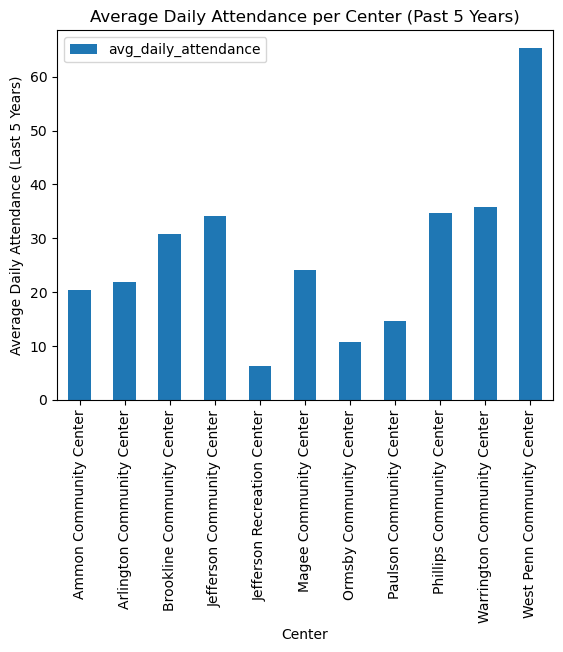

In [9]:
avg_daily_last_5.plot(
    x="center_name",
    y="avg_daily_attendance",
    kind="bar"
)

plt.xlabel("Center")
plt.ylabel("Average Daily Attendance (Last 5 Years)")
plt.title("Average Daily Attendance per Center (Past 5 Years)")
plt.show()

# Conclusion
West Penn Community Center(North Oakland/Oakland), shows high total annual attendance and average daily attendance, along with relatively consistent year over year growth. Warrington Community Center(Southside) and Phillips Community Center(Carrick) also showed high year over year growth and high annual attendance.